In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import  StandardScaler
from sklearn.decomposition import  PCA


In [2]:
data = pd.read_csv('AI_index_db.csv')

In [3]:
data.head()

,Country,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,Total score,Region,Cluster,Income group,Political regime
0,United States of America,100.00,94.02,64.56,100.00,100.00,77.39,100.00,100.00,Americas,Power players,High,Liberal democracy
1,China,16.51,100.00,91.57,71.42,79.97,94.87,44.02,62.92,Asia-Pacific,Power players,Upper middle,Closed autocracy
2,United Kingdom,39.65,71.43,74.65,36.50,25.03,82.82,18.91,40.93,Europe,Traditional champions,High,Liberal democracy
3,Canada,31.28,77.05,93.94,30.67,25.78,100.00,14.88,40.19,Americas,Traditional champions,High,Liberal democracy
4,Israel,35.76,67.58,82.44,32.63,27.96,43.91,27.33,39.89,Middle East,Rising stars,High,Liberal democracy


In [4]:
features = [
    'Talent', 'Infrastructure', 'Operating Environment', 
    'Research', 'Development', 'Government Strategy', 'Commercial'
]
metadata = ['Country', 'Region', 'Cluster', 'Income group', 'Political regime']

# 2. Drop any rows with missing values in our features
df_clean = data.dropna(subset=features).copy()

# 3. Standardize the numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[features])

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 5. Create a new DataFrame with the PCA results and metadata
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
for col in metadata:
    df_pca[col] = df_clean[col].values

explained_variance = pca.explained_variance_ratio_
print(f"PC1 explains: {explained_variance[0]:.2%}")
print(f"PC2 explains: {explained_variance[1]:.2%}")
print(f"Total information retained: {sum(explained_variance):.2%}")

PC1 explains: 58.15%
PC2 explains: 19.14%
Total information retained: 77.29%


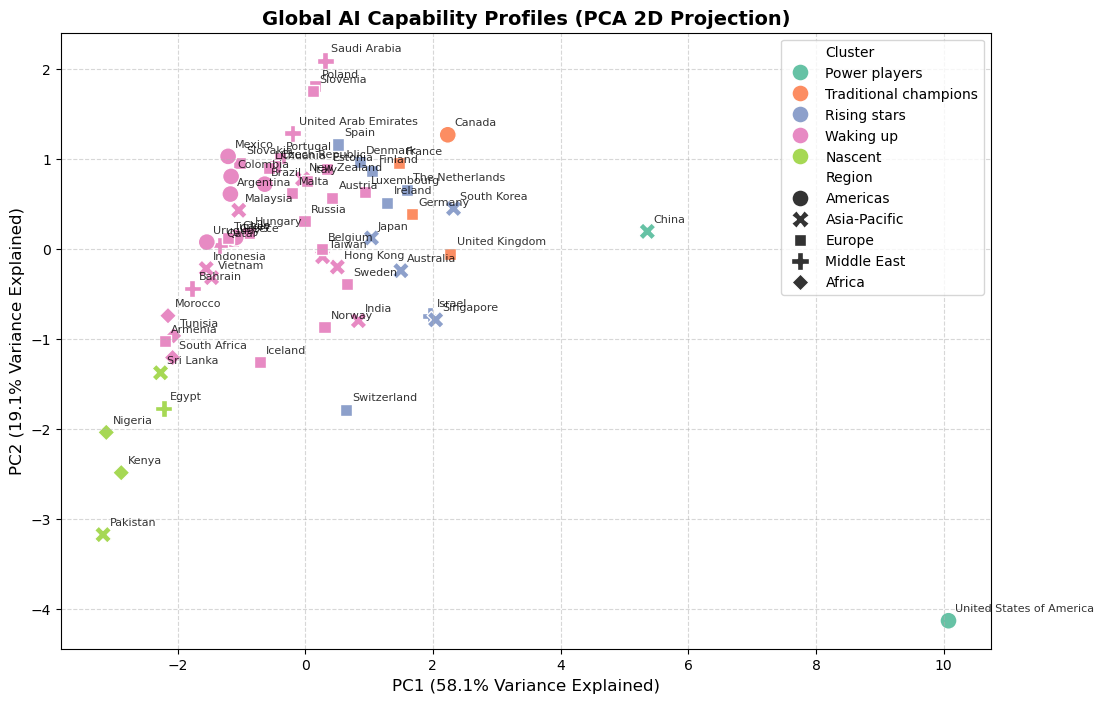

In [9]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    style='Region',
    data=df_pca, 
    s=150, 
    palette='Set2'
)

# Annotate country names on the plot
for i, country in enumerate(df_pca['Country']):
    plt.text(df_pca['PC1'][i] + 0.1, df_pca['PC2'][i] + 0.1, country, fontsize=8, alpha=0.8)

plt.title('Global AI Capability Profiles (PCA 2D Projection)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({explained_variance[0]:.1%} Variance Explained)', fontsize=12)
plt.ylabel(f'PC2 ({explained_variance[1]:.1%} Variance Explained)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Save the plot automatically for your GitHub repository
plt.savefig('ai_index_pca.png', dpi=300, bbox_inches='tight')
plt.show()